<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (needed for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Simple CNN model
def create_model():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)), # Explicit Input layer to address Keras UserWarning
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

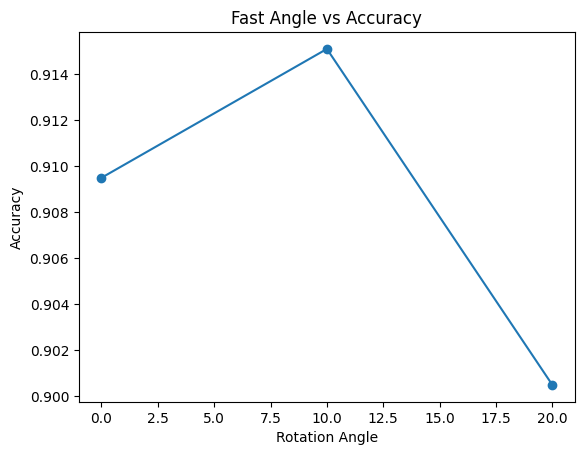

In [8]:
angles = [0, 10, 20]
angle_acc = []

X_train_small = X_train[:10000]
y_train_small = y_train_cat[:10000]

for angle in angles:
    datagen = ImageDataGenerator(rotation_range=angle)

    model = create_model()

    model.fit(datagen.flow(X_train_small, y_train_small, batch_size=64),
              steps_per_epoch=100,
              epochs=1,
              verbose=0)

    acc = model.evaluate(X_test, y_test_cat, verbose=0)[1]
    angle_acc.append(acc)

# Plot
plt.figure()
plt.plot(angles, angle_acc, marker='o')
plt.xlabel("Rotation Angle")
plt.ylabel("Accuracy")
plt.title("Fast Angle vs Accuracy")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


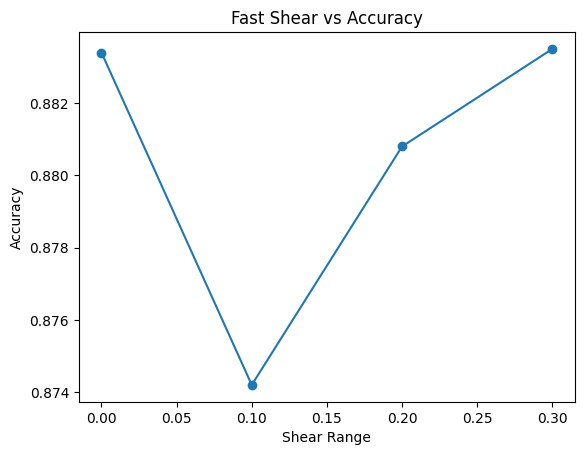

In [11]:
shears = [0.0, 0.1, 0.2, 0.3]
shear_acc = []

# Reduce dataset size
X_train_small = X_train[:10000]
y_train_small = y_train_cat[:10000]

# Faster model
def create_fast_model():
    from tensorflow.keras import models, layers
    model = models.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

for shear in shears:
    datagen = ImageDataGenerator(shear_range=shear)

    model = create_fast_model()

    model.fit(datagen.flow(X_train_small, y_train_small, batch_size=64),
              steps_per_epoch=100,   # limit training
              epochs=1,              # reduce epochs
              verbose=0)

    acc = model.evaluate(X_test, y_test_cat, verbose=0)[1]
    shear_acc.append(acc)

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(shears, shear_acc, marker='o')
plt.xlabel("Shear Range")
plt.ylabel("Accuracy")
plt.title("Fast Shear vs Accuracy")
plt.show()

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2
)

model = create_model()

model.fit(datagen.flow(X_train, y_train_cat, batch_size=64),
          epochs=5)

acc = model.evaluate(X_test, y_test_cat)[1]
print("Combined Augmentation Accuracy:", acc)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step - accuracy: 0.9235 - loss: 0.2616
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9689 - loss: 0.1041
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.9753 - loss: 0.0802
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9786 - loss: 0.0698
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.9814 - loss: 0.0595
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9857 - loss: 0.0425
Combined Augmentation Accuracy: 0.9857000112533569


In [13]:
datagen = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.3,
    zoom_range=0.3
)

model = create_model()

# More steps → more augmented samples
model.fit(datagen.flow(X_train, y_train_cat, batch_size=64),
          steps_per_epoch=200,
          epochs=5)

acc = model.evaluate(X_test, y_test_cat)[1]
print("High Augmentation Accuracy:", acc)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.7669 - loss: 0.7684
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9095 - loss: 0.3233
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9331 - loss: 0.2330
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9416 - loss: 0.1883
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9530 - loss: 0.1665


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9741 - loss: 0.0836
High Augmentation Accuracy: 0.9740999937057495


In [14]:
X_small = []
y_small = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][:50]
    X_small.append(X_train[idx])
    y_small.append(y_train_cat[idx])

X_small = np.vstack(X_small)
y_small = np.vstack(y_small)

model = create_model()

model.fit(X_small, y_small, epochs=5)

acc = model.evaluate(X_test, y_test_cat)[1]
print("Accuracy with 50 images per digit:", acc)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4920 - loss: 1.8179
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8180 - loss: 0.7874
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8580 - loss: 0.4447
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9020 - loss: 0.3237
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9120 - loss: 0.2602
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8532 - loss: 0.4871
Accuracy with 50 images per digit: 0.8532000184059143
